# ---stationarity---

### Stationarity means the statistical behavior of a time series stays stable over time.
### in simple words - The series follows the same rules today, tomorrow, and next year.(That means properties like average, spread, and dependence structure do not keep changing.)

## ----Formal Meaning (Weak Stationarity)----

#### 1. Constant Mean (Same average at all times.)
#### 2. Constant Variance (Spread remains stable.)
#### 3. Covariance Depends Only on Lag (Correlation between values depends on distance apart, not calendar time.)      (cov(s1)=cov(s2))
#### cov(Xn,Xn+k)=cov(Xm,Xm+k) example-cov(X1,X4)=cov(X3=X6)

## NOTE 1- White noise is stationarity, Random walk is not stationary(because variance grows over time,mean drifts)

## NOTE 2-when we say stationarity we mean strict stationarity which mean S1 and S2 follows identical distribution (where S1 and S2 samples of identical size from the data )

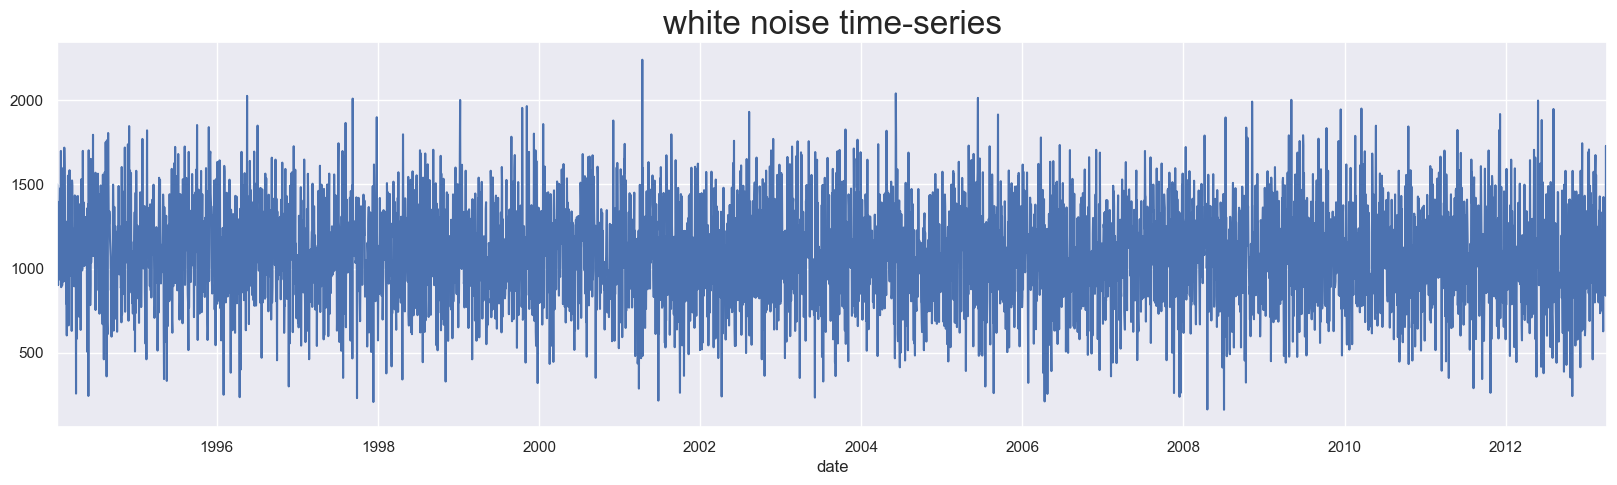

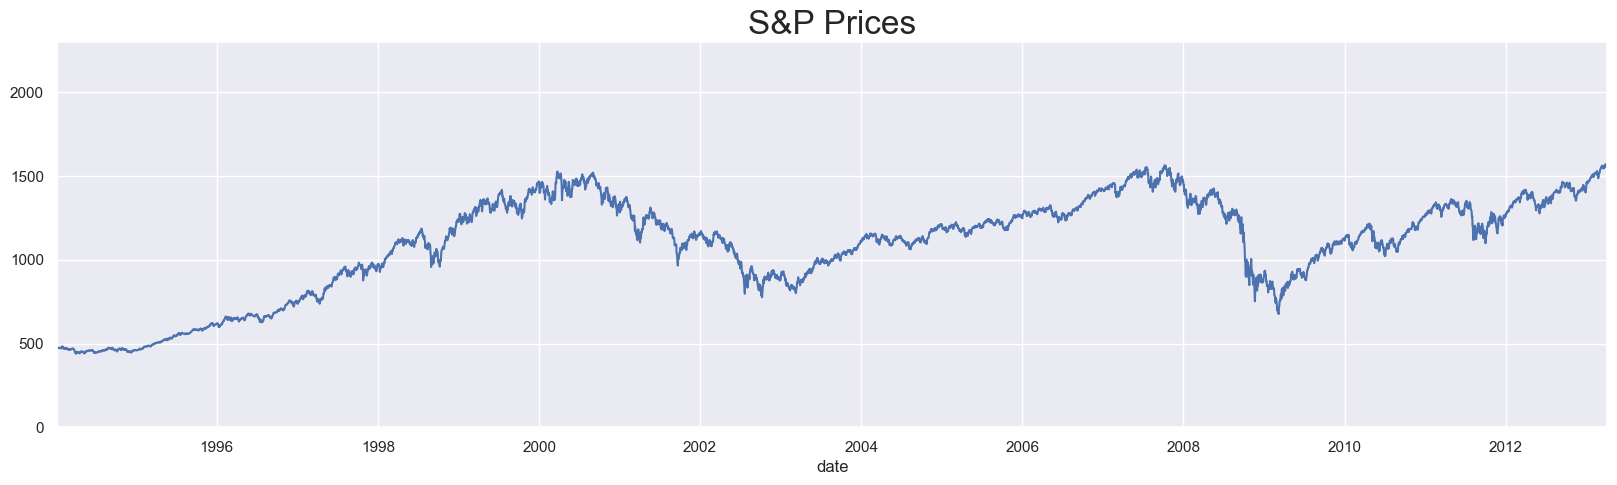

In [61]:
# the test for stationarity and non-stationarity is known as Dicky-Fuller test or DF test
# null hyposthesis assums non-stationarity
# if test statistic < critical value then we reject the null hyposthesis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
df.wn.plot(figsize=(20,5))
plt.title("white noise time-series",size=24)
plt.show()
df.market_value.plot(figsize=(20,5))
plt.title("S&P Prices",size=24)
plt.ylim(0,2300)
plt.show()
rw=pd.read_csv("Randwalk.csv")
rw.date=pd.to_datetime(rw.date, dayfirst=True)
rw.set_index("date",inplace=True)
rw=rw.asfreq('b')
rw.describe()
df['rw']=rw.price

In [62]:
sts.adfuller(df.market_value)
## here p-value is not small so we can't reject null hypothesis

(np.float64(-1.7369847452352447),
 np.float64(0.4121645696770616),
 18,
 5002,
 {'1%': np.float64(-3.431658008603046),
  '5%': np.float64(-2.862117998412982),
  '10%': np.float64(-2.567077669247375)},
 np.float64(39904.880607487445))

In [63]:
sts.adfuller(df.wn)
# here we can see p-value is zero so null hypothesis is rejected implies the data is stationarity

(np.float64(-72.31974421472052),
 0.0,
 0,
 5020,
 {'1%': np.float64(-3.431653316130827),
  '5%': np.float64(-2.8621159253018247),
  '10%': np.float64(-2.5670765656497516)},
 np.float64(70827.21982707956))

In [64]:
sts.adfuller(df.rw)
# here teh p-value is not small so null hypothesis is not rejected 

(np.float64(-1.3286073927689706),
 np.float64(0.615984918161739),
 24,
 4996,
 {'1%': np.float64(-3.4316595802782865),
  '5%': np.float64(-2.8621186927706463),
  '10%': np.float64(-2.567078038881065)},
 np.float64(46299.333497595144))

# --------------------------------------------------------------------------------

# ***STATIONARITY***

### ***A stationary time series is one whose statistical properties do not change over time. In other words, it has a constant mean, variance, and autocorrelation, and these properties are independent of time.***

### Many forecasting models assume stationarity. The moving average model, autoregressive model, and autoregressive moving average model  all assume stationarity. These models can only be used if we verify that the data is indeed stationary. Otherwise, the models will not be valid, and the forecasts will not be reliable. Intuitively, this makes sense, because if the data is non-stationary, its properties are going to change over time, which would mean that our model parameters must also change through time. This means that we cannot possibly derive a function of future values as a function of past values, since the coefficients change at each point in time, making forecasting unreliable.
### We can view stationarity as an assumption that can make our lives easier when forecasting. Of course, we will rarely see a stationary time series in its original state because we are often interested in forecasting processes with a trend or with seasonal cycles. This is when models like ARIMA and SARIMA come into play.

## ****-------TRANSFORMATION IN TIME SERIES FORCASTING-----****
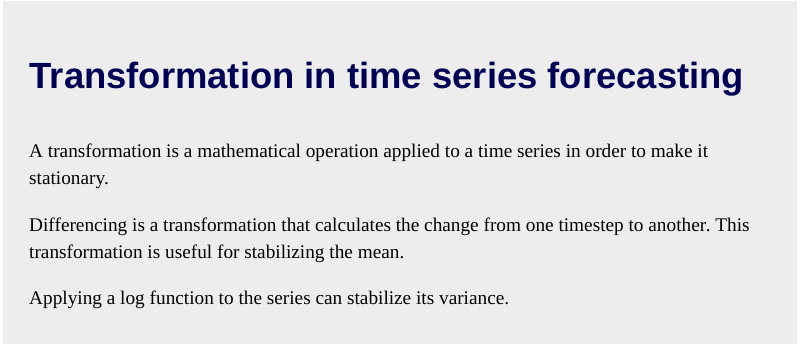

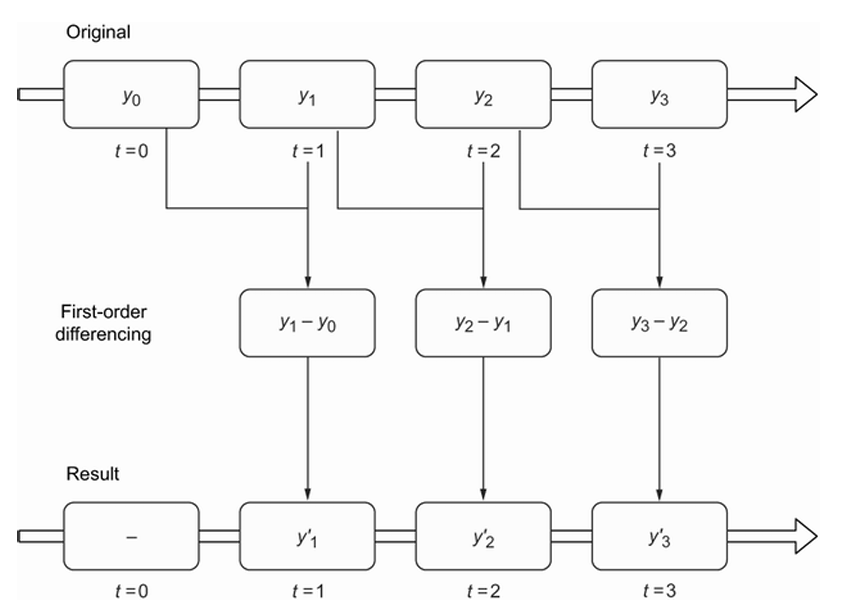
### *Visualizing the differencing transformation. Here, a first order differencing is applied. Notice how we lose one data point after this transformation because the initial point in time cannot be differenced with previous values since they do not exist.*

### **It is possible to difference a time-series many times. Taking the difference once is applying a fist-order differencing. Taking the difference twice would be second-order differencing.It is often not necessary to difference more than twice to obtain a stationary series.**

### **While differencing is used to obtain a constant mean through time, we must also make sure we have a constant variance in order for our process to be stationary. Logarithms are used to help stabilize the variance.**

## **keep in mind at the time of modeling the data we need to untransform the data**

# ****-----TESTING FOR STATIONARITY-----****

### ***Once a transformation is applied to a time series, we need to test for stationarity to determine if we need to apply another transformation to make the time series stationary, or if we need to transform it at all. A common test is the augmented Dickey-Fuller (ADF) test.***

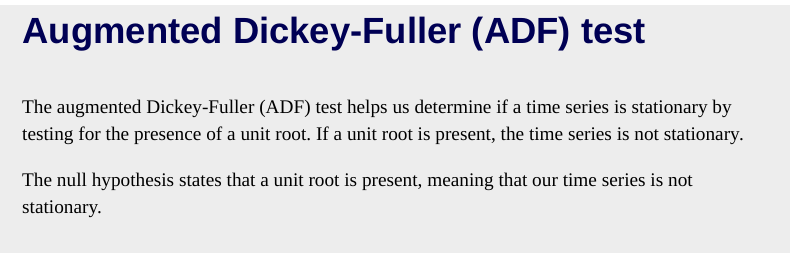

### the general equation of time series is 
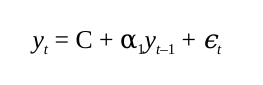
### if α1 lies between -1 and 1 then the series is stationary otherwise not.
### if p-value is > 0.05 then it means that fail to reject null hypothesis means unit root is present which implies series is not stationary.
 

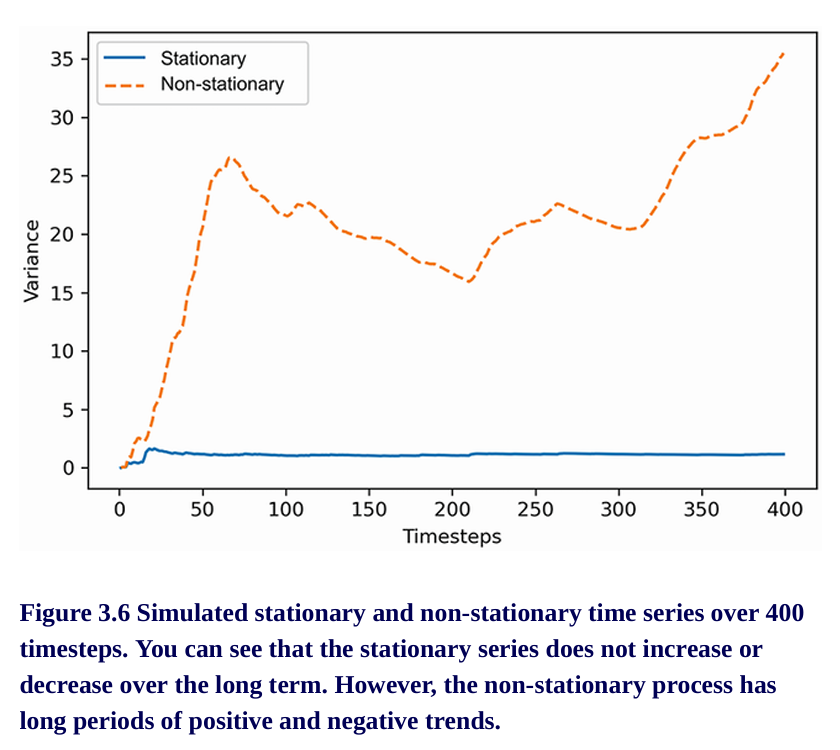

## ***----NOW WE HAVE TO CHECK IF THE RANDOM WALK IS STATIONARY OR NOT----***

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [66]:
df_new = pd.read_csv('GOOGL_2020-04-28_to_2021-04-27.csv',index_col=0)

In [67]:
# This code creates 1000 random up/down steps and adds them cumulatively to simulate a random path.
np.random.seed(42) # gives always same result without it the output would be different everytime                         
steps = np.random.standard_normal(1000) #Generate 1000 random numbers from a standard normal distribution.
# Each number is one step movement:
# positive = move up
# negative = move down
steps[0]=0 #Set the first step to zero.
# So instead of random starting jump, the walk begins at 0.                   
random_walk = np.cumsum(steps) #Take cumulative sum of all steps.

In [68]:
sts.adfuller(random_walk)

(np.float64(-0.9659524876918751),
 np.float64(0.7654789696692581),
 0,
 999,
 {'1%': np.float64(-3.4369127451400474),
  '5%': np.float64(-2.864437475834273),
  '10%': np.float64(-2.568312754566378)},
 np.float64(2735.41783678331))

### In the above code we can see the p-value is >0.05 and test statistic > table value so the random walk is not stationary.
### ***NOTE-->***  **Random walk is not stationary because variance increases over time.**

## ***PLOTTING THE "ACF " PLOT***

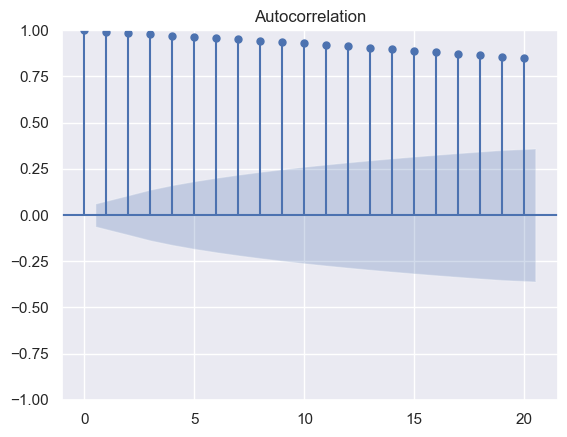

In [69]:
plot_acf(random_walk,lags=20);

### ***Plot of the ACF of our simulated random walk. Notice how the autocorrelation coefficients slowly decrease. Even at lag 20, the value is still autocorrelated, which means that our random walk is not stationary at the moment.***

## ***----MAKING THE RANDOM WALK DATA STATIONARY----***

In [70]:
diff_random_walk=np.diff(random_walk,n=1)

### **----plotting the diff_random_walk----**

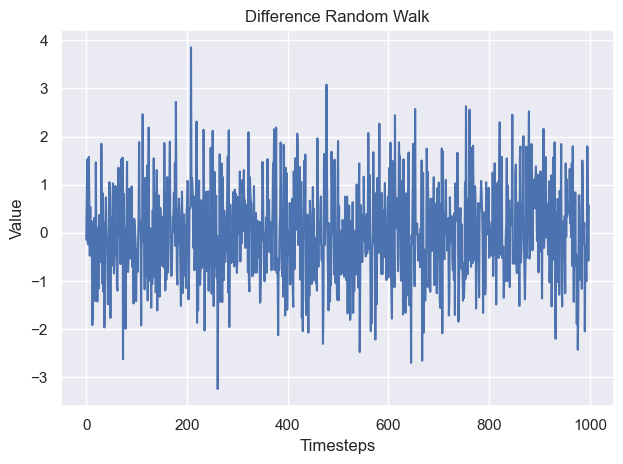

In [71]:
plt.plot(diff_random_walk)
plt.title('Difference Random Walk')
plt.xlabel('Timesteps')
plt.ylabel('Value')
plt.tight_layout()


## **Evolution of our differenced random walk. It seems that we successfully removed the trend and that the variance is stable.**

In [72]:
sts.adfuller(diff_random_walk)

(np.float64(-31.789310857560615),
 0.0,
 0,
 998,
 {'1%': np.float64(-3.4369193380671),
  '5%': np.float64(-2.864440383452517),
  '10%': np.float64(-2.56831430323573)},
 np.float64(2732.189035830486))

## Now we can se the p-value is < 0.05 and test statstic > table value so our data is stationary

## **PLOTTING THE "ACF" PLOT AGAIN**

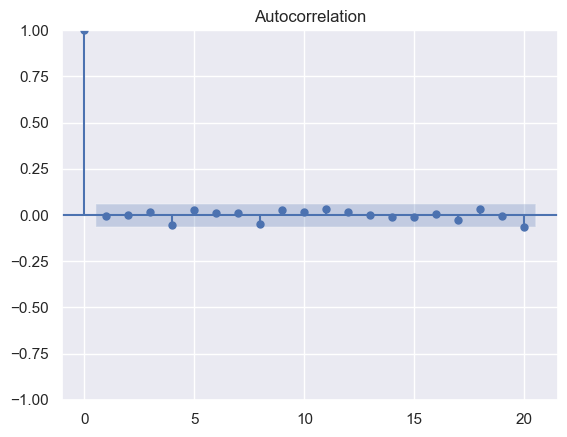

In [73]:
plot_acf(diff_random_walk,lags=20);

### ***An ACF plot of our differenced random walk. Notice how there are no significant coefficients after lag 0. This is a clear indicator that we are dealing with a random walk.***

# ***Is GOOGL a random walk?***

### ***PLOTTING THE DATA OF GOOGL***

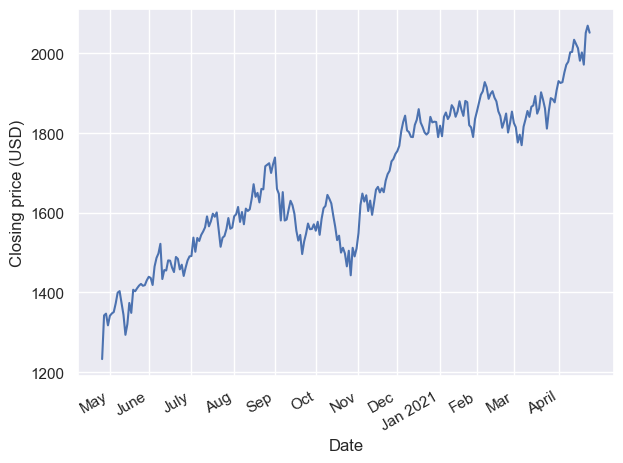

In [74]:
fig, ax = plt.subplots()

ax.plot(df_new['Date'], df_new['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

plt.xticks(
    [4, 24, 46, 68, 89, 110, 132, 152, 174, 193, 212, 235], 
    ['May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2021', 'Feb', 'Mar', 'April'])

fig.autofmt_xdate()
plt.tight_layout()

### **we can see a trend in the data as the closing price is increasing over time; therefore, we do not have a stationary process**

## ***NOW APPLYING THE "ADF" TEST TO CHECK OUR ASSUMPTION THAT DATA IS NOT STATIONARY***

In [75]:
sts.adfuller(df_new['Close']) 

(np.float64(-0.8057661014709223),
 np.float64(0.817422448342754),
 1,
 250,
 {'1%': np.float64(-3.456780859712),
  '5%': np.float64(-2.8731715065600003),
  '10%': np.float64(-2.572968544)},
 np.float64(2220.625756002486))

### ***Here we can see that the p-value is < 0.05 and test statistic < table value so the data is not stationary.***

### **NOW WE WILL DIFFERENCE OUR DATA TO SEE IF THAT MAKES IT STATSIONARY**

In [77]:
diff_close = np.diff(df_new['Close'], n=1)

In [79]:
# Next, we can run the ADF test on the differenced data:
sts.adfuller(diff_close)

(np.float64(-19.48907934288492),
 0.0,
 0,
 250,
 {'1%': np.float64(-3.456780859712),
  '5%': np.float64(-2.8731715065600003),
  '10%': np.float64(-2.572968544)},
 np.float64(2210.585567545333))

### **Now we can see that the p-value < 0.05 and test-statistic < table value implies that the data is stationaru**

## **NOW WE CAN PLOT "ACF" PLOT**

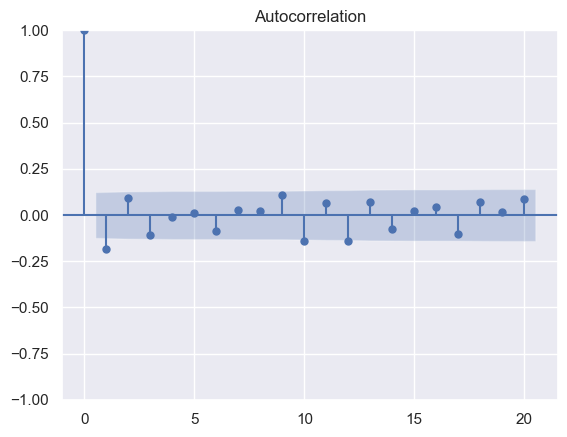

In [80]:
plot_acf(diff_close,lags=20);

## ***We can see that there are no significant coefficients in the ACF plot. You might notice that at lags 2 and 11 the coefficients are significant, while the others are not. This happens by chance with some data, and these points can be assumed to be non-significant, because we do not have consecutive significant coefficients between lags 0 and 2 or lags 0 and 11.**

### Therefore, we can conclude that the closing price of GOOGL can be approximated by a random walk process. Taking the first difference makes the series stationary, and its ACF plot shows no autocorrelation, meaning that it is purely random.